In [1]:
!pip install --upgrade transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# ══════════════════════════════════════════════════════════════════
# CELL 0 │ INSTALL REQUIREMENTS  (Colab — run once)
# ══════════════════════════════════════════════════════════════════
# NOTE: Runtime > Change runtime type > T4 GPU  ← do this first!

!pip install -q \
    torch torchaudio \
    librosa soundfile \
    scikit-learn \
    matplotlib seaborn \
    fastapi uvicorn python-multipart \

print("✅ All packages installed.")

✅ All packages installed.


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 │ MOUNT GOOGLE DRIVE & UNZIP DAIC-WOZ
# ══════════════════════════════════════════════════════════════════
# Upload your daic-woz.zip to Google Drive, then update ZIP_PATH.
# Expected zip structure: daic-woz/300_P/300_AUDIO.wav
#                                        300_TRANSCRIPT.csv
#                         daic-woz/train_split_Depression_AVEC2017.csv
#                         daic-woz/dev_split_Depression_AVEC2017.csv

from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

# ── ⚠  UPDATE THIS PATH ──────────────────────────────────────────
ZIP_PATH    = "/content/drive/MyDrive/DAIC-WOZ.zip"  # your zip location
EXTRACT_TO  = "/content/daic-woz"                    # where to extract
# ─────────────────────────────────────────────────────────────────

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP not found: {ZIP_PATH}\n"
        "Please upload daic-woz.zip to your Drive and update ZIP_PATH above."
    )

if os.path.exists(EXTRACT_TO):
    print("ℹ️  Dataset folder already exists — skipping extraction.")
else:
    print("📦 Unzipping DAIC-WOZ dataset (this may take ~1-2 min)...")
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print("✅ Extraction complete.")

# Peek inside
sample_items = sorted(os.listdir(EXTRACT_TO))[:8]
print(f"📁 Contents preview: {sample_items}")

Mounted at /content/drive
📦 Unzipping DAIC-WOZ dataset (this may take ~1-2 min)...
✅ Extraction complete.
📁 Contents preview: ['DAIC-WOZ']


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 │ IMPORTS & PATH SETUP
# ══════════════════════════════════════════════════════════════════
import os
import glob
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import soundfile as sf
from sklearn.metrics import classification_report, confusion_matrix
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split

# ── Colab paths ───────────────────────────────────────────────────
DAIC_WOZ_DIR = "/content/daic-woz/DAIC-WOZ"            # extracted dataset root
OUTPUT_DIR   = "/content/voice_artifacts"      # EDA / frontend assets
MODEL_DIR    = "/content/saved_wav2vec2_model" # trained model checkpoint

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Paths mapped successfully.")
print(f"   Dataset  : {DAIC_WOZ_DIR}")
print(f"   Artifacts: {OUTPUT_DIR}")
print(f"   Model    : {MODEL_DIR}")
print(f"   Device   : {DEVICE}  {'(GPU ✅)' if DEVICE=='cuda' else '(CPU ⚠️ — training will be slow)'}")

✅ Paths mapped successfully.
   Dataset  : /content/daic-woz/DAIC-WOZ
   Artifacts: /content/voice_artifacts
   Model    : /content/saved_wav2vec2_model
   Device   : cuda  (GPU ✅)


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 │ DATASET MATCHING & VALIDATION  [logic unchanged]
# ══════════════════════════════════════════════════════════════════


# 1. Load the master labels from the dataset folder
train_csv_path = os.path.join(DAIC_WOZ_DIR, "train_split_Depression_AVEC2017.csv")
dev_csv_path   = os.path.join(DAIC_WOZ_DIR, "dev_split_Depression_AVEC2017.csv")

try:
    df_train = pd.read_csv(train_csv_path)
    df_dev   = pd.read_csv(dev_csv_path)
    df_all_labels = pd.concat([df_train, df_dev])
    # Clean leading/trailing spaces from column names
    df_all_labels.columns = df_all_labels.columns.str.strip()
except FileNotFoundError:
    print(f"ERROR: Could not find the split CSVs in {DAIC_WOZ_DIR}.")
    print("Please ensure the CSVs are in that folder.")
    raise

# 2. Find which _P folders actually exist
existing_folders = glob.glob(os.path.join(DAIC_WOZ_DIR, "*_P"))
existing_ids = [int(os.path.basename(f).split("_")[0]) for f in existing_folders]

# 3. Filter the dataframe to ONLY include IDs we have downloaded
df_valid = df_all_labels[df_all_labels['Participant_ID'].isin(existing_ids)].copy()

print(f"Total labels in CSVs        : {len(df_all_labels)}")
print(f"Downloaded folders found    : {len(existing_ids)}")
print(f"Final valid matched patients: {len(df_valid)}")
display(df_valid.head())

Total labels in CSVs        : 142
Downloaded folders found    : 55
Final valid matched patients: 47


,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,303,0,0,0,0,0,0.0,0,0,0,0,0
4,312,0,2,1,0,0,1.0,1,0,0,0,0
5,313,0,7,1,1,1,1.0,1,1,1,1,0
63,402,1,11,0,1,1,2.0,1,2,2,1,1
67,415,0,3,0,0,0,1.0,1,1,0,0,0


In [6]:
# ══════════════════════════════════════════════════════════════════
# CELL 4 │ AUDIO SLICING & CHUNKING  [logic unchanged]
# ══════════════════════════════════════════════════════════════════
TARGET_SR            = 16000  # Wav2Vec2 strictly requires 16 kHz audio
CHUNK_LENGTH_S       = 10     # 10 seconds per chunk
MAX_CHUNKS_PER_PATIENT = 5    # Prevent one talkative patient from dominating the dataset

audio_dataset = []

for index, row in df_valid.iterrows():
    p_id  = int(row['Participant_ID'])
    label = int(row['PHQ8_Binary'])

    folder_path    = os.path.join(DAIC_WOZ_DIR, f"{p_id}_P")
    audio_file     = os.path.join(folder_path, f"{p_id}_AUDIO.wav")
    transcript_file = os.path.join(folder_path, f"{p_id}_TRANSCRIPT.csv")

    if not os.path.exists(audio_file) or not os.path.exists(transcript_file):
        print(f"  ⚠️  Missing files for Patient {p_id}, skipping...")
        continue

    try:
        # DAIC-WOZ sometimes uses tabs even in .csv files
        df_trans = pd.read_csv(transcript_file, sep='\t')
        if 'speaker' not in df_trans.columns:
            df_trans = pd.read_csv(transcript_file)
    except Exception as e:
        print(f"  ⚠️  Error reading transcript for {p_id}: {e}")
        continue

    # Filter for Participant only (remove Ellie the interviewer)
    df_trans.columns = df_trans.columns.str.strip()
    df_participant = df_trans[df_trans['speaker'] == 'Participant']

    # Load the full audio waveform once
    waveform, sr = librosa.load(audio_file, sr=TARGET_SR)

    chunks_extracted = 0
    for _, t_row in df_participant.iterrows():
        if chunks_extracted >= MAX_CHUNKS_PER_PATIENT:
            break

        start_samp = int(t_row['start_time'] * TARGET_SR)
        end_samp   = int(t_row['stop_time']  * TARGET_SR)

        # Only take segments that are at least 3 seconds long
        if (end_samp - start_samp) / TARGET_SR > 3.0:
            patient_audio = waveform[start_samp:end_samp]

            # Pad or truncate to exact CHUNK_LENGTH_S
            target_length = TARGET_SR * CHUNK_LENGTH_S
            if len(patient_audio) > target_length:
                patient_audio = patient_audio[:target_length]
            else:
                patient_audio = np.pad(
                    patient_audio,
                    (0, max(0, target_length - len(patient_audio))),
                    "constant"
                )

            audio_dataset.append({
                "patient_id": p_id,
                "array": patient_audio,
                "label": label
            })
            chunks_extracted += 1

print(f"✅ Extraction complete. Total fixed-length chunks created: {len(audio_dataset)}")

✅ Extraction complete. Total fixed-length chunks created: 235


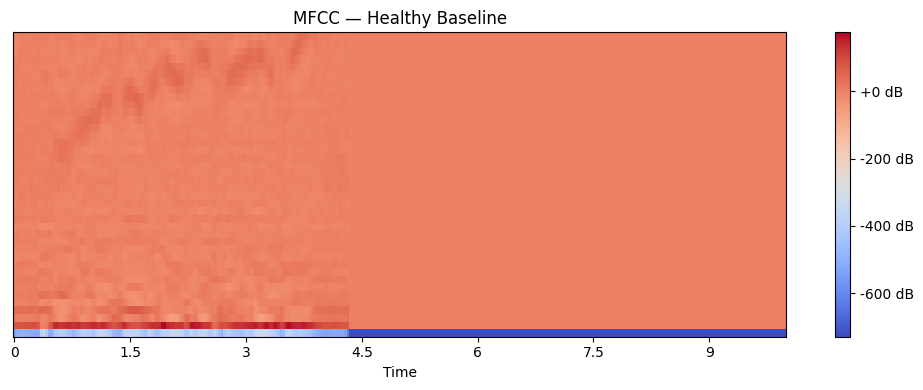

  Saved → /content/voice_artifacts/healthy_spectrogram.png


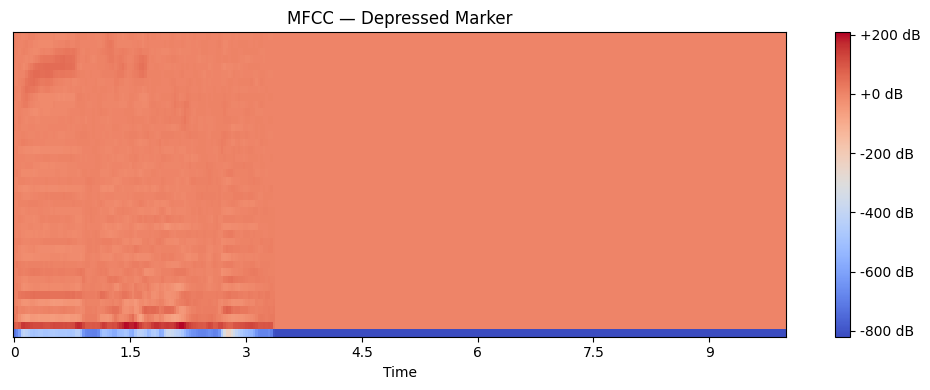

  Saved → /content/voice_artifacts/depressed_spectrogram.png


/tmp/ipykernel_6013/4132155922.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=chunk_labels, palette=["#4CAF50", "#F44336"])
/tmp/ipykernel_6013/4132155922.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Healthy (0)", "Depressed (1)"])


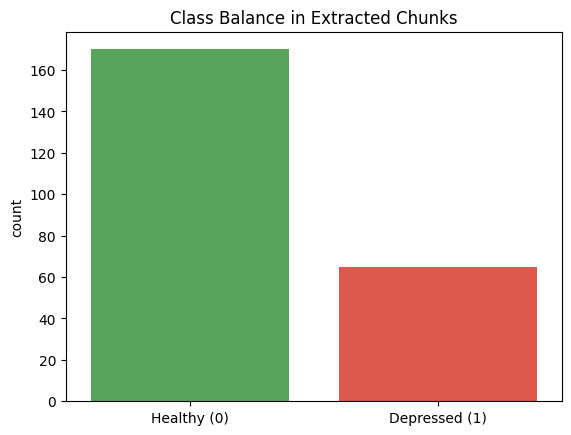

  Label distribution: {np.int64(0): np.int64(170), np.int64(1): np.int64(65)}


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELL 5 │ EDA & FRONTEND ASSET EXPORT  [logic unchanged]
# ══════════════════════════════════════════════════════════════════
# Generate a spectrogram for the first depressed and first healthy chunk
healthy_chunk   = next(item for item in audio_dataset if item["label"] == 0)
depressed_chunk = next(item for item in audio_dataset if item["label"] == 1)

def plot_and_save_spectrogram(audio_array, title, filename):
    plt.figure(figsize=(10, 4))
    mfccs = librosa.feature.mfcc(y=audio_array, sr=TARGET_SR, n_mfcc=40)
    librosa.display.specshow(mfccs, x_axis='time', sr=TARGET_SR)
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"  Saved → {save_path}")

plot_and_save_spectrogram(healthy_chunk["array"],   "MFCC — Healthy Baseline",   "healthy_spectrogram.png")
plot_and_save_spectrogram(depressed_chunk["array"], "MFCC — Depressed Marker",   "depressed_spectrogram.png")

# Class balance check
chunk_labels = [x["label"] for x in audio_dataset]
ax = sns.countplot(x=chunk_labels, palette=["#4CAF50", "#F44336"])
ax.set_xticklabels(["Healthy (0)", "Depressed (1)"])
plt.title("Class Balance in Extracted Chunks")
plt.savefig(os.path.join(OUTPUT_DIR, "class_balance.png"))
plt.show()
print(f"  Label distribution: {dict(zip(*np.unique(chunk_labels, return_counts=True)))}")

In [8]:
# ══════════════════════════════════════════════════════════════════
# CELL 6 │ PRE-CACHED DATASET SETUP  [logic unchanged]
# ══════════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# 1. Load the pretrained Wav2Vec2 feature extractor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

# 2. Split data (80 % train, 20 % test) — stratified
train_data, test_data = train_test_split(
    audio_dataset,
    test_size=0.2,
    random_state=42,
    stratify=[x["label"] for x in audio_dataset]
)

# 3. Compute class weights dynamically based on the training split
train_labels = [x["label"] for x in train_data]
computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
print(f"Class Weights → Healthy (0): {computed_weights[0]:.4f} | Depressed (1): {computed_weights[1]:.4f}")

# 4. PRE-EXTRACT: removes audio processing from the hot training loop
def pre_extract_features(data_list, is_train=False):
    processed_items = []
    for item in data_list:
        audio_array = item["array"].copy()

        # Light Gaussian noise augmentation (training only)
        if is_train and np.random.rand() < 0.5:
            noise_amp = 0.008 * np.random.uniform() * np.amax(audio_array)
            audio_array = audio_array + noise_amp * np.random.normal(size=audio_array.shape[0])

        inputs = processor(audio_array, sampling_rate=16000, return_tensors="pt")
        processed_items.append({
            "input_values": inputs.input_values.squeeze(0),
            "labels": torch.tensor(item["label"], dtype=torch.long)
        })
    return processed_items

print("Pre-extracting audio features into memory...")
processed_train_data = pre_extract_features(train_data, is_train=True)
processed_eval_data  = pre_extract_features(test_data,  is_train=False)

class AstroMindVoiceDataset(torch.utils.data.Dataset):
    def __init__(self, processed_list):
        self.data = processed_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = AstroMindVoiceDataset(processed_train_data)
eval_dataset  = AstroMindVoiceDataset(processed_eval_data)

print(f"✅ Dataset cached. Training: {len(train_dataset)} | Validation: {len(eval_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Class Weights → Healthy (0): 0.6912 | Depressed (1): 1.8077
Pre-extracting audio features into memory...
✅ Dataset cached. Training: 188 | Validation: 47


In [9]:
# ══════════════════════════════════════════════════════════════════
# CELL 7 │ UNIFIED HIGH-RECALL & ANTI-OVERFITTING TRAINING
# ══════════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np
from transformers import (
    EarlyStoppingCallback, Trainer, TrainingArguments,
    Wav2Vec2ForSequenceClassification
)

# ── 1. CUSTOM METRICS WITH THE RECALL THRESHOLD ────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert raw logits into probabilities (0.0 to 1.0)
    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()

    # 🔥 RECALL BOOST: Lower decision boundary from 0.50 to 0.35
    DEPRESSION_THRESHOLD = 0.35
    preds = (probs[:, 1] >= DEPRESSION_THRESHOLD).astype(int)

    # Calculate macro F1 based on our medical diagnostic threshold
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    acc = (preds == labels).mean()

    # Print real-time updates to your console during training logs
    rec_depressed = recall_score(labels, preds, pos_label=1, zero_division=0)
    prec_depressed = precision_score(labels, preds, pos_label=1, zero_division=0)
    print(f"\n  [Validation Check] Depressed Recall: {rec_depressed:.2f} | Precision: {prec_depressed:.2f}")

    return {"f1": f1, "accuracy": acc}

# ── 2. WEIGHTED-LOSS TRAINER (CLASS IBALANCE FIX) ─────────────────────
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float).to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )
        return (loss, outputs) if return_outputs else loss

# ── 3. MODEL INITIALIZATION (WITH ANTI-OVERFITTING DROPOUTS) ──────────
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2,
    attention_dropout=0.2,   # 🛡️ Anti-overfitting: heavy attention dropout
    hidden_dropout=0.2,      # 🛡️ Anti-overfitting: heavy hidden layer dropout
    feat_proj_dropout=0.1,   # 🛡️ Anti-overfitting: feature projection dropout
)

# Freeze CNN feature encoder to safeguard low-level audio extraction
model.freeze_feature_encoder()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

# ── 4. TRAINING ARGUMENTS (ALL REGULARIZATION PARAMETERS INTACT) ──────
use_fp16 = torch.cuda.is_available()

training_args = TrainingArguments(
    output_dir                  = MODEL_DIR,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",

    # ── Speed & learning pacing ───────────────────────────────
    num_train_epochs            = 15,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 8,
    gradient_accumulation_steps = 1,          # Frequent updates to break out of underfitting

    # ── 🛡️ ALL YOUR ANTI-OVERFITTING HYPERPARAMETERS 🛡️ ────────
    learning_rate               = 3e-5,       # Conservative learning speed
    lr_scheduler_type           = "cosine",   # Smooth mathematical learning decay
    warmup_ratio                = 0.10,       # 10% steps dedicated to a gentle ramp-up
    weight_decay                = 0.05,       # Stronger L2 regularization penalization
    label_smoothing_factor      = 0.10,       # Prevents the model from becoming over-confident

    # ── Checkpointing & execution ──────────────────────────────
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",       # Optimizes for your custom clinical threshold F1
    greater_is_better           = True,
    fp16                        = use_fp16,
    dataloader_num_workers      = 2,
    report_to                   = "none",
)

# ── 5. 🔥 RECALL PENALTY BOOST ────────────────────────────────────────
# Artificially scale up the penalty for missing a depressed patient by 1.5x
boosted_weights = computed_weights.copy()
boosted_weights[1] = boosted_weights[1] * 1.5

# ── 6. INITIALIZE AND START TRAINING ──────────────────────────────────
trainer = WeightedLossTrainer(
    class_weights  = boosted_weights,
    model          = model,
    args           = training_args,
    train_dataset  = train_dataset,
    eval_dataset   = eval_dataset,
    compute_metrics= compute_metrics,
    # Extended patience to ensure the model survives the rocky first 4 epochs
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=6)]
)

import time
print(f"🚀 Starting training on device: {training_args.device}")
t0 = time.time()
trainer.train()
print(f"\n⏱  Training finished in {(time.time()-t0)/60:.1f} min")

trainer.save_model(MODEL_DIR)
processor.save_pretrained(MODEL_DIR)
print(f"✅ Best high-recall model saved to → {MODEL_DIR}")



pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `w

Trainable params: 90,368,642 / 94,569,090  (95.6%)
🚀 Starting training on device: cuda:0


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

...


  [Validation Check] Depressed Recall: 0.92 | Precision: 0.92


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


⏱  Training finished in 10.9 min


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Best high-recall model saved to → /content/saved_wav2vec2_model



  [Validation Check] Depressed Recall: 0.92 | Precision: 0.92

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97        34
   Depressed       0.92      0.92      0.92        13

    accuracy                           0.96        47
   macro avg       0.95      0.95      0.95        47
weighted avg       0.96      0.96      0.96        47

ROC-AUC : 0.9276


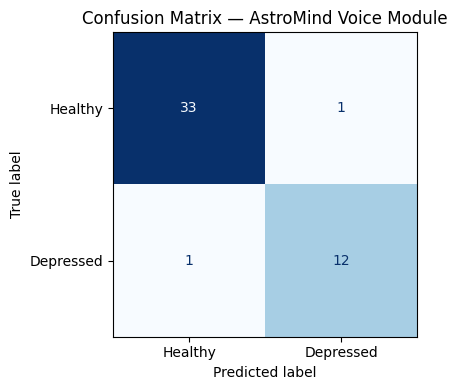


✅ Confusion matrix saved → /content/voice_artifacts/confusion_matrix.png

  True Negatives  (correctly healthy)  : 33
  False Positives (healthy → flagged)   : 1
  False Negatives (missed depression)   : 1  ← most critical
  True Positives  (correctly depressed) : 12


In [10]:
# ══════════════════════════════════════════════════════════════════
# CELL 8 │ MODEL EVALUATION
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# ── Run inference on the held-out eval set ───────────────────────
predictions = trainer.predict(eval_dataset)
logits      = predictions.predictions
true_labels = predictions.label_ids
pred_labels = np.argmax(logits, axis=-1)

# Probabilities for AUC
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]

# ── Console report ───────────────────────────────────────────────
print("\n📊 CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(
    true_labels, pred_labels,
    target_names=["Healthy", "Depressed"]
))

try:
    auc = roc_auc_score(true_labels, probs)
    print(f"ROC-AUC : {auc:.4f}")
except Exception:
    print("(ROC-AUC requires both classes in eval set)")

# ── Confusion matrix plot ─────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Depressed"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — AstroMind Voice Module")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"\n✅ Confusion matrix saved → {OUTPUT_DIR}/confusion_matrix.png")

# ── Per-class breakdown ───────────────────────────────────────────
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
print(f"\n  True Negatives  (correctly healthy)  : {tn}")
print(f"  False Positives (healthy → flagged)   : {fp}")
print(f"  False Negatives (missed depression)   : {fn}  ← most critical")
print(f"  True Positives  (correctly depressed) : {tp}")

In [11]:
# ══════════════════════════════════════════════════════════════════
# CELL 9 │ TESTING BLOCK — inference on a single audio file
# ══════════════════════════════════════════════════════════════════
# Usage:
#   Option A — use any .wav file from DAIC-WOZ
#   Option B — upload your own file via Colab files panel
#   Then set TEST_AUDIO_PATH below and run.

from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import librosa, torch, numpy as np

# ── ⚠  SET THE PATH TO YOUR TEST AUDIO ──────────────────────────
TEST_AUDIO_PATH = "/content/daic-woz/DAIC-WOZ/303_P/303_AUDIO.wav"  #
KNOWN_LABEL     = None   # set to 0 (healthy) or 1 (depressed) if known
# ─────────────────────────────────────────────────────────────────

# Load the saved model (can be run in a fresh session too)
_processor = Wav2Vec2Processor.from_pretrained(MODEL_DIR)
_model     = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR)
_model.eval()

TARGET_SR_TEST  = 16000
CHUNK_DUR_TEST  = 10          # seconds
MAX_TEST_CHUNKS = 3           # average prediction over N chunks

def predict_audio(audio_path: str) -> dict:
    """
    Loads an audio file, slices it into fixed chunks,
    runs inference on each, and returns an ensemble result.
    Returns dict ready for the FastAPI response schema.
    """
    waveform, _ = librosa.load(audio_path, sr=TARGET_SR_TEST)
    chunk_len   = TARGET_SR_TEST * CHUNK_DUR_TEST

    all_probs = []
    for i in range(MAX_TEST_CHUNKS):
        start = i * chunk_len
        end   = start + chunk_len
        if start >= len(waveform):
            break
        chunk = waveform[start:end]
        # Pad last chunk if needed
        if len(chunk) < chunk_len:
            chunk = np.pad(chunk, (0, chunk_len - len(chunk)), "constant")

        inputs  = _processor(chunk, sampling_rate=TARGET_SR_TEST, return_tensors="pt")
        with torch.no_grad():
            logits = _model(**inputs).logits
        probs   = torch.softmax(logits, dim=-1).squeeze().tolist()
        all_probs.append(probs)

    mean_probs       = np.mean(all_probs, axis=0)
    pred_label       = int(np.argmax(mean_probs))
    confidence       = float(mean_probs[pred_label])
    label_str        = "depressed" if pred_label == 1 else "healthy"

    return {
        "prediction"        : label_str,
        "label_int"         : pred_label,
        "confidence"        : round(confidence, 4),
        "healthy_prob"      : round(float(mean_probs[0]), 4),
        "depressed_prob"    : round(float(mean_probs[1]), 4),
        "chunks_analyzed"   : len(all_probs),
        "risk_flag"         : confidence > 0.70 and pred_label == 1,
    }

# ── Run the test ──────────────────────────────────────────────────
if not os.path.exists(TEST_AUDIO_PATH):
    print(f"❌ File not found: {TEST_AUDIO_PATH}")
    print("   Update TEST_AUDIO_PATH to a valid .wav file.")
else:
    result = predict_audio(TEST_AUDIO_PATH)

    print("\n🔬 AstroMind Voice Diagnostic Result")
    print("=" * 40)
    for k, v in result.items():
        print(f"  {k:<22}: {v}")

    if KNOWN_LABEL is not None:
        match = "✅ CORRECT" if result["label_int"] == KNOWN_LABEL else "❌ WRONG"
        print(f"\n  Ground truth: {'depressed' if KNOWN_LABEL==1 else 'healthy'}  →  {match}")

    if result["risk_flag"]:
        print("\n  ⚠️  HIGH-CONFIDENCE DEPRESSION FLAG — LLM module should be notified.")

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]


🔬 AstroMind Voice Diagnostic Result
  prediction            : healthy
  label_int             : 0
  confidence            : 0.6438
  healthy_prob          : 0.6438
  depressed_prob        : 0.3562
  chunks_analyzed       : 3
  risk_flag             : False


In [12]:
# ══════════════════════════════════════════════════════════════════
# CELL 10 │ FASTAPI ROUTER  ← copy to 1_voice_module/voice_api.py
# ══════════════════════════════════════════════════════════════════
fastapi_code = '''
"""
AstroMind — Voice Diagnostic FastAPI Router
File: 1_voice_module/voice_api.py

Mounted in app.py via:
    from voice_module.voice_api import router as voice_router
    app.include_router(voice_router, prefix="/voice", tags=["Voice Diagnostics"])
"""

import io
import numpy as np
import torch
import librosa
import soundfile as sf
from pathlib import Path
from functools import lru_cache

from fastapi import APIRouter, UploadFile, File, HTTPException
from pydantic import BaseModel
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

router = APIRouter()

# ── Model path — update before deploying ────────────────────────
MODEL_PATH = Path(__file__).parent / "saved_wav2vec2_model"

TARGET_SR    = 16000
CHUNK_DUR    = 10          # seconds per inference chunk
MAX_CHUNKS   = 3           # ensemble over N chunks

# ── Lazy-loaded singleton (loaded once on first request) ─────────
@lru_cache(maxsize=1)
def get_model():
    if not MODEL_PATH.exists():
        raise RuntimeError(f"Model not found at {MODEL_PATH}. Run the notebook first.")
    processor = Wav2Vec2Processor.from_pretrained(str(MODEL_PATH))
    model     = Wav2Vec2ForSequenceClassification.from_pretrained(str(MODEL_PATH))
    model.eval()
    return processor, model


# ── Response schema (frontend contract) ──────────────────────────
class VoiceDiagnosticResponse(BaseModel):
    prediction:       str    # "healthy" | "depressed"
    label_int:        int    # 0 | 1
    confidence:       float  # 0.0 – 1.0
    healthy_prob:     float
    depressed_prob:   float
    chunks_analyzed:  int
    risk_flag:        bool   # True if confidence > 0.70 and depressed
    model_version:    str


def _run_inference(waveform: np.ndarray) -> VoiceDiagnosticResponse:
    processor, model = get_model()
    chunk_len = TARGET_SR * CHUNK_DUR
    all_probs = []

    for i in range(MAX_CHUNKS):
        start = i * chunk_len
        if start >= len(waveform):
            break
        chunk = waveform[start : start + chunk_len]
        if len(chunk) < chunk_len:
            chunk = np.pad(chunk, (0, chunk_len - len(chunk)), "constant")

        inputs = processor(chunk, sampling_rate=TARGET_SR, return_tensors="pt")
        with torch.no_grad():
            logits = model(**inputs).logits
        all_probs.append(torch.softmax(logits, dim=-1).squeeze().tolist())

    if not all_probs:
        raise HTTPException(status_code=422, detail="Audio too short (< 1 s).")

    mean_probs  = np.mean(all_probs, axis=0)
    pred_label  = int(np.argmax(mean_probs))
    confidence  = float(mean_probs[pred_label])

    return VoiceDiagnosticResponse(
        prediction      = "depressed" if pred_label == 1 else "healthy",
        label_int       = pred_label,
        confidence      = round(confidence, 4),
        healthy_prob    = round(float(mean_probs[0]), 4),
        depressed_prob  = round(float(mean_probs[1]), 4),
        chunks_analyzed = len(all_probs),
        risk_flag       = confidence > 0.70 and pred_label == 1,
        model_version   = "wav2vec2-base-astromind-v1",
    )


# ── Endpoints ─────────────────────────────────────────────────────

@router.post("/diagnose", response_model=VoiceDiagnosticResponse)
async def diagnose_voice(file: UploadFile = File(...)):
    """
    Upload a .wav audio clip. Returns a depression risk assessment.
    Accepts: audio/wav, audio/x-wav, audio/mpeg
    """
    allowed = {"audio/wav", "audio/x-wav", "audio/mpeg", "application/octet-stream"}
    if file.content_type not in allowed:
        raise HTTPException(status_code=415, detail=f"Unsupported media type: {file.content_type}")

    raw = await file.read()
    try:
        audio_buf = io.BytesIO(raw)
        waveform, sr = sf.read(audio_buf)
        if waveform.ndim > 1:              # stereo → mono
            waveform = waveform.mean(axis=1)
        if sr != TARGET_SR:
            waveform = librosa.resample(waveform.astype(np.float32), orig_sr=sr, target_sr=TARGET_SR)
    except Exception as e:
        raise HTTPException(status_code=422, detail=f"Could not read audio file: {e}")

    return _run_inference(waveform.astype(np.float32))


@router.get("/health")
async def health_check():
    """Liveness probe — returns model load status."""
    try:
        get_model()
        return {"status": "ok", "model": "loaded"}
    except RuntimeError as e:
        return {"status": "error", "detail": str(e)}
'''

# Save to /content/voice_api.py for easy download
out_path = "/content/voice_api.py"
with open(out_path, "w") as f:
    f.write(fastapi_code.strip())

print(f"✅ voice_api.py written to {out_path}")
print("   → In Colab: Files panel (left sidebar) → download it")
print("   → Place at: astromind-project/1_voice_module/voice_api.py")
print("\nFastAPI Endpoint Summary:")
print("  POST /voice/diagnose  — upload .wav → VoiceDiagnosticResponse JSON")
print("  GET  /voice/health    — liveness probe")

✅ voice_api.py written to /content/voice_api.py
   → In Colab: Files panel (left sidebar) → download it
   → Place at: astromind-project/1_voice_module/voice_api.py

FastAPI Endpoint Summary:
  POST /voice/diagnose  — upload .wav → VoiceDiagnosticResponse JSON
  GET  /voice/health    — liveness probe


## 📦 Frontend Team — Integration Guide

---

### Endpoint
```
POST /voice/diagnose
Content-Type: multipart/form-data
Field: file  (audio/wav)
```

### Response Schema (JSON)
```json
{
  "prediction":       "healthy" | "depressed",
  "label_int":        0 | 1,
  "confidence":       0.87,
  "healthy_prob":     0.13,
  "depressed_prob":   0.87,
  "chunks_analyzed":  3,
  "risk_flag":        true,
  "model_version":    "wav2vec2-base-astromind-v1"
}
```

### Field Descriptions
| Field | Type | Use in UI |
|---|---|---|
| `prediction` | string | Label badge — green/red |
| `confidence` | float 0–1 | Confidence bar / radial gauge |
| `depressed_prob` | float 0–1 | Detailed prob display |
| `risk_flag` | bool | Trigger intervention banner (`confidence > 0.70`) |
| `chunks_analyzed` | int | "Analysis based on N audio segments" tooltip |
| `model_version` | string | Footer attribution |



### Visual Assets (saved to `/content/voice_artifacts/`)
| File | Purpose |
|---|---|
| `healthy_spectrogram.png` | MFCC baseline illustration |
| `depressed_spectrogram.png` | Depression acoustic marker illustration |
| `class_balance.png` | Training data distribution |
| `confusion_matrix.png` | Model performance matrix |

### Error Codes
| Code | Meaning |
|---|---|
| 415 | Wrong file type — must be `.wav` |
| 422 | Corrupt audio or clip < 1 second |
| 500 | Model not loaded (run notebook first) |